In [1]:
print("Hello World!")

Hello World!


In [2]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

dataset = LeRobotDataset(
    repo_id="lerobot/libero_spatial_image",
    root="../datasets/libero_spatial_image"  # wherever you downloaded it
)

/home/vansh/projects/VLA_journey/Dum-E/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(len(dataset))
print(dataset[0].keys())

52970
dict_keys(['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


In [4]:
print(dataset.meta.features["observation.state"])

{'dtype': 'float32', 'shape': (8,), 'names': {'motors': ['x', 'y', 'z', 'rx', 'ry', 'rz', 'rw', 'gripper']}, 'fps': 10}


In [5]:
sample = dataset[10]

print(sample["observation.images.image"].shape)

torch.Size([3, 256, 256])


In [6]:
print(sample["task"])

pick up the black bowl next to the cookie box and place it on the plate


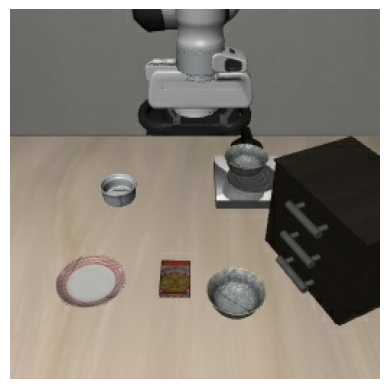

In [7]:
import matplotlib.pyplot as plt
image = sample["observation.images.image"]
image = image.detach().cpu()

if image.shape[0] in [1, 3, 4]:
    image = image.permute(1, 2, 0)


image = image.numpy()
plt.imshow(image)
plt.axis("off")
plt.show()

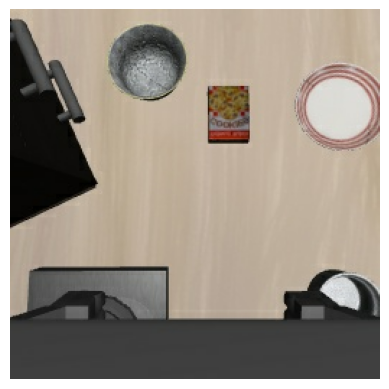

In [8]:
image = sample["observation.images.wrist_image"]
image = image.detach().cpu()

if image.shape[0] in [1, 3, 4]:
    image = image.permute(1, 2, 0)


image = image.numpy()
plt.imshow(image)
plt.axis("off")
plt.show()

In [9]:
print(sample["observation.state"])

tensor([-0.1307, -0.0110,  1.1640,  3.1331,  0.0079,  0.1382,  0.0392, -0.0393])


In [10]:
print(sample["action"])

tensor([ 0.9375,  0.0000, -0.2304, -0.0129, -0.0675,  0.0086, -1.0000])


In [ ]:
delta_timestamps = {
        "action": [i / 10.0 for i in range(50)],  # fps=10 for LIBERO
    }
dataset = LeRobotDataset(
        repo_id="lerobot/libero_spatial_image",
        root="../datasets/libero_spatial_image",
        delta_timestamps=delta_timestamps,
    )

Fetching 75 files: 100%|██████████| 75/75 [01:00<00:00,  1.25it/s]


In [15]:
sample = dataset[10]

print(sample["observation.images.image"].shape)

torch.Size([3, 256, 256])


In [16]:
print(sample["task"])

pick up the black bowl next to the cookie box and place it on the plate


In [17]:
print(sample["observation.state"])

tensor([-0.1307, -0.0110,  1.1640,  3.1331,  0.0079,  0.1382,  0.0392, -0.0393])


In [19]:
print(sample["action"].shape)

torch.Size([50, 7])
